# Exercise 2 — Machine learning for carbon-capture process design

**Completed solution**

In this exercise, you will build and evaluate a reproducible neural-network surrogate for a packed carbon-capture column. You will then combine the surrogate with differential evolution to optimize operating and design conditions. An optional extension compares the Keras model with linear regression.

## Learning objectives

After completing this exercise, you will be able to:

- formulate a supervised regression problem;
- create training and test datasets;
- standardize inputs and outputs without leaking test information;
- construct and train a reproducible multi-output neural network with Keras;
- evaluate predictions using $R^2$, RMSE, and parity plots;
- apply differential evolution to optimize process conditions within defined bounds;
- assess an optimized condition against data-domain and physical limitations;
- optionally benchmark the neural network against linear regression.

## 1. Load and inspect the data

The dataset contains six inputs describing the packed column and two outputs describing its performance. Import the libraries needed for data handling and visualization at the beginning of this section.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

Upload `carbon_capture_data.csv` to the Colab session before running the next cell. Use pandas to load the file into a DataFrame named `df`.

In [2]:
df = pd.read_csv("carbon_capture_data.csv")

Use `df.head()` to examine the first five observations and verify that the columns were loaded correctly.

In [3]:
df.head()

,GFR,LFR,Temp,CO2alpha,CO2pp,Height,kGa,eta
0,668.089,7.486,58.661,0.058,5.002,27.1,1.703692,0.999997
1,926.180,7.047,42.728,0.408,11.652,17.9,0.816135,0.831406
2,577.428,6.746,57.503,0.147,1.135,15.4,1.573468,0.940200
3,630.101,6.629,49.330,0.282,19.894,19.6,0.348648,0.626329
4,719.154,8.363,46.134,0.309,14.130,5.1,0.466150,0.479614


Check the dimensions of the dataset. Each row is one process observation and each column is one variable.

In [4]:
print("Rows and columns:", df.shape)

Rows and columns: (300, 8)


Missing values require a deliberate treatment before model training. Count the missing values in every column.

In [5]:
print(df.isna().sum())

GFR         0
LFR         0
Temp        0
CO2alpha    0
CO2pp       0
Height      0
kGa         0
eta         0
dtype: int64


Use `describe()` to examine the ranges and scales of the numerical variables.

In [6]:
df.describe()

,GFR,LFR,Temp,CO2alpha,CO2pp,Height,kGa,eta
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,549.959163,5.999780,59.998997,0.225013,10.498883,17.501333,0.843587,0.732183
std,260.195327,2.313533,11.567128,0.130139,5.493646,7.227118,0.597670,0.203815
min,101.380000,2.006000,40.097000,0.001000,1.030000,5.000000,0.016732,0.471522
25%,325.450250,4.001250,50.010250,0.112750,5.775750,11.275000,0.382686,0.533520
50%,550.323500,5.991500,59.968000,0.224500,10.505500,17.550000,0.722122,0.683904
75%,773.917500,8.003000,70.002500,0.336500,15.224750,23.725000,1.116179,0.967372
max,999.643000,9.985000,79.999000,0.449000,19.945000,29.900000,2.483268,1.000000


A histogram provides a quick view of a variable's distribution. Plot the distribution of the gas flow rate per column area.

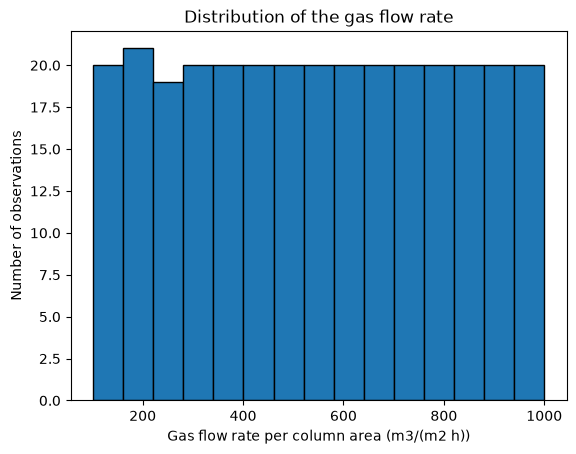

In [7]:
plt.hist(df["GFR"], bins=15, edgecolor="black")
plt.xlabel("Gas flow rate per column area (m3/(m2 h))")
plt.ylabel("Number of observations")
plt.title("Distribution of the gas flow rate")
plt.show()

## 2. Formulate the regression problem

The model inputs are the gas and liquid flow rates per area, temperature, initial CO₂ loading, CO₂ partial pressure, and packed-column height. The two targets are the volumetric mass-transfer coefficient and capture efficiency.

In [8]:
feature_names = ["GFR", "LFR", "Temp", "CO2alpha", "CO2pp", "Height"]
target_names = ["kGa", "eta"]

Select the input and output columns from `df`, then convert both selections to NumPy arrays. The `feature_names` and `target_names` lists preserve the meaning and order of the array columns.

In [9]:
X = df[feature_names].to_numpy()
y = df[target_names].to_numpy()

In [10]:
print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (300, 6)
Output shape: (300, 2)


## 3. Create training and test data

The model learns from the training set. The test set remains unseen during training and provides an estimate of predictive performance on new observations.

The split is made reproducible by setting `random_state=42` directly when `train_test_split` is called.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
print("Training observations:", X_train.shape[0])
print("Test observations:", X_test.shape[0])

Training observations: 240
Test observations: 60


The variables have very different numerical ranges. Standardization subtracts the training mean and divides by the training standard deviation.

The scalers must be fitted only on the training data. The same fitted transformations are then applied to the test data.

In [14]:
X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

## 4. Train a Keras neural-network surrogate

The neural network has six inputs, three hidden layers with ten neurons each, and two outputs. ReLU activation introduces nonlinear behavior in the hidden layers. The output layer is linear because this is a regression problem.

The libraries, model construction, model compilation, and model summary are separated below so that each operation can be examined independently.

### Neural-network architecture

<img
  src="https://raw.githubusercontent.com/udicaprio/FlowCat_SummerSchool/main/Exercise_2_Machine_Learning/neural_network_architecture.svg"
  width="800"
/>

<i>Figure generated with <a href="https://github.com/alexlenail/NN-SVG">NN-SVG</a>.</i>

In [15]:
import keras
from keras import layers
from matplotlib import pyplot as plt

### Construct the neural network

Set the Keras seed immediately before constructing the model. Start with an empty sequential model and add the input, hidden, and output layers one at a time.

In [16]:
keras.utils.set_random_seed(42)

neural_model = keras.Sequential()

neural_model.add(keras.Input(shape=(X_train_scaled.shape[1],)))
neural_model.add(layers.Dense(10, activation="relu"))
neural_model.add(layers.Dense(10, activation="relu"))
neural_model.add(layers.Dense(10, activation="relu"))
neural_model.add(layers.Dense(y_train_scaled.shape[1], activation="linear"))

### Configure the training

Compile the model using the Adam optimizer and mean squared error as the loss function.

In [17]:
neural_model.compile(optimizer="adam", loss="mean_squared_error")

### Inspect the model

Show the model summary and verify the number of layers, the output shape, and the number of trainable parameters.

In [18]:
neural_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 312 (1.22 KB)

 Trainable params: 312 (1.22 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

A portion of the training data is reserved for validation so that the training and validation losses can be examined. During training, Keras will show a compact progress bar for each epoch. `loss` is the mean squared error on the training subset, while `val_loss` is calculated on the validation subset. Both values refer to the standardized outputs.

<details>
<summary><strong>What is the validation set?</strong></summary>

The validation set is a subset of the available data kept separate from parameter fitting. It is used during model development to compare candidate settings, monitor generalization, and identify overfitting. Training performance may continue to improve while validation performance deteriorates, indicating that the model is fitting the training data too closely. Unlike the validation set, the test set should remain untouched until the final evaluation.

</details>

In [ ]:
history = neural_model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    verbose=1,
)

print("Final training loss:", history.history["loss"][-1])
print("Final validation loss:", history.history["val_loss"][-1])

Plot the loss history. The curves show how the mean squared error changes across the training epochs.

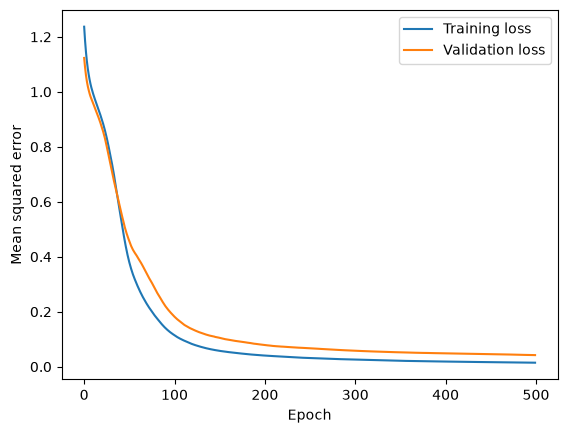

In [20]:
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.legend()
plt.show()

Generate predictions for the standardized test inputs. The neural network returns predictions in the standardized output space.

In [21]:
neural_test_scaled = neural_model.predict(X_test_scaled, verbose=0)

Convert the scaled predictions back to the original physical scale and keep the result as a NumPy array. Following `target_names`, column 0 contains `kGa` and column 1 contains `eta`.

In [22]:
neural_test_pred = y_scaler.inverse_transform(neural_test_scaled)

Inspect the inverse-transformed prediction array. Its rows correspond to test observations and its two columns correspond to the targets in `target_names`.

In [23]:
neural_test_pred

,kGa,eta
0,0.225072,0.661107
1,1.357490,0.688325
2,0.262644,0.532746
3,0.983889,0.506862
4,0.961799,0.572246
5,0.065280,0.455551
6,0.669696,0.925563
7,0.852795,0.552739
8,1.402277,0.637104
9,2.237314,1.012590


## 5. Evaluate the neural network

Import the metric and visualization functions required in this section. Then calculate one coefficient of determination ($R^2$) and one root mean squared error (RMSE) for each output using the unseen test observations.

In [ ]:
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error

In [ ]:
r2_ann_kga = r2_score(y_test[:, 0], neural_test_pred[:, 0])
rmse_ann_kga = root_mean_squared_error(y_test[:, 0], neural_test_pred[:, 0])
r2_ann_eta = r2_score(y_test[:, 1], neural_test_pred[:, 1])
rmse_ann_eta = root_mean_squared_error(y_test[:, 1], neural_test_pred[:, 1])

Print the $R^2$ and RMSE values for each output so that they can be read and compared directly.

In [ ]:
print("R2 kGa:", r2_ann_kga)
print("RMSE kGa:", rmse_ann_kga)
print("R2 eta:", r2_ann_eta)
print("RMSE eta:", rmse_ann_eta)

A parity plot places reference values on the x-axis and predictions on the y-axis. Predictions close to the diagonal line agree with the data.

First create a parity plot for the volumetric mass-transfer coefficient.

In [ ]:
kga_bounds = [y_test[:, 0].min(), y_test[:, 0].max()]

plt.scatter(
    y_test[:, 0],
    neural_test_pred[:, 0],
    alpha=0.7,
    label="Keras neural network",
)
plt.plot(kga_bounds, kga_bounds, "k--", label="Ideal prediction")
plt.xlabel("Reference kGa")
plt.ylabel("Predicted kGa")
plt.legend()
plt.show()

Now create a parity plot for the capture efficiency.

In [ ]:
eta_bounds = [y_test[:, 1].min(), y_test[:, 1].max()]

plt.scatter(
    y_test[:, 1],
    neural_test_pred[:, 1],
    alpha=0.7,
    label="Keras neural network",
)
plt.plot(eta_bounds, eta_bounds, "k--", label="Ideal prediction")
plt.xlabel("Reference capture efficiency")
plt.ylabel("Predicted capture efficiency")
plt.legend()
plt.show()

## 6. Optimize operating and design conditions with differential evolution

The algorithm minimizes an objective function. To maximize the predicted mass-transfer coefficient, the objective returns the negative predicted `kGa`.

Only gas flow rate per area, liquid flow rate per area, temperature, and column height are optimized. CO₂ loading and partial pressure remain fixed. Every decision-variable bound is taken from the training data, so the optimizer does not deliberately extrapolate beyond the individual observed ranges.

<details>
<summary><strong>How differential evolution works</strong></summary>

Differential evolution maintains a population of candidate solutions. For each candidate, it creates a trial solution by combining differences between other population members. The trial replaces the original candidate when it gives a better objective value. Repeating mutation, recombination, and selection moves the population toward promising regions without requiring gradients. Because the search is stochastic, repeated runs can differ unless a random seed is set.

<p align="center"><img src="https://upload.wikimedia.org/wikipedia/commons/e/e0/Ackley.gif" alt="Differential evolution optimizing the two-dimensional Ackley function" width="602"></p>

*Differential evolution optimizing the two-dimensional Ackley function with a population of 20.* Animation by [Pablormier](https://commons.wikimedia.org/wiki/User:Pablormier), via [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Ackley.gif), licensed under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).

</details>

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import differential_evolution

Print the minimum and maximum training value for each input. These ranges will define the finite search interval for each optimized variable.

In [ ]:
print("GFR bounds:", X_train[:, 0].min(), X_train[:, 0].max())
print("LFR bounds:", X_train[:, 1].min(), X_train[:, 1].max())
print("Temperature bounds:", X_train[:, 2].min(), X_train[:, 2].max())
print("CO2 loading bounds:", X_train[:, 3].min(), X_train[:, 3].max())
print("CO2 partial-pressure bounds:", X_train[:, 4].min(), X_train[:, 4].max())
print("Column-height bounds:", X_train[:, 5].min(), X_train[:, 5].max())

Define the fixed process requirements used in the optimization.

In [ ]:
total_gas_flow_m3_h = 20_000
fixed_co2_loading = 0.1
fixed_co2_partial_pressure_kPa = 10.0

Select the four decision variables and create one lower-and-upper bound pair for each variable from the training data.

In [ ]:
decision_names = ["GFR", "LFR", "Temp", "Height"]
decision_indices = [feature_names.index(name) for name in decision_names]
decision_bounds = [(X_train[:, index].min(), X_train[:, index].max()) for index in decision_indices]

print("GFR optimization bounds:", decision_bounds[0][0], decision_bounds[0][1])
print("LFR optimization bounds:", decision_bounds[1][0], decision_bounds[1][1])
print("Temperature optimization bounds:", decision_bounds[2][0], decision_bounds[2][1])
print("Column-height optimization bounds:", decision_bounds[3][0], decision_bounds[3][1])

Define a reusable function that converts one differential-evolution candidate into a NumPy array containing the six model inputs, standardizes it, evaluates the neural network, and returns `kGa` and `eta` in their physical scales. The array values follow the same order as `feature_names`.

The model is called directly because the optimizer evaluates this function many times.

In [ ]:
def predict_performance(decision_variables):
    condition = np.array(
        [
            [
                decision_variables[0],
                decision_variables[1],
                decision_variables[2],
                fixed_co2_loading,
                fixed_co2_partial_pressure_kPa,
                decision_variables[3],
            ]
        ]
    )
    condition_scaled = X_scaler.transform(condition)
    prediction_scaled = np.asarray(
        neural_model(condition_scaled, training=False)
    )
    return y_scaler.inverse_transform(prediction_scaled)[0]

Define the optimization objective. Differential evolution minimizes this function, so returning negative `kGa` converts the desired maximization into a minimization problem.

In [ ]:
def objective(decision_variables):
    return -predict_performance(decision_variables)[0]

Run differential evolution using the objective and decision-variable bounds. The local random seed makes the stochastic population reproducible. After the population-based search, polishing applies a local optimization step to refine the best solution.

In [ ]:
optimization_result = differential_evolution(
    objective,
    decision_bounds,
    rng=42,
)

Inspect the optimizer status. Differential evolution returns the best decision vector found, the objective value, the number of model evaluations, and information about why the search stopped.

In [ ]:
print("Optimization successful:", optimization_result.success)
print("Termination message:", optimization_result.message)
print("Objective evaluations:", optimization_result.nfev)

Evaluate the selected decision vector once more and collect the optimized inputs and predicted outputs in a labelled Series.

In [ ]:
optimal_prediction = predict_performance(optimization_result.x)

best_condition = pd.Series(
    {
        "GFR": optimization_result.x[0],
        "LFR": optimization_result.x[1],
        "Temp": optimization_result.x[2],
        "CO2alpha": fixed_co2_loading,
        "CO2pp": fixed_co2_partial_pressure_kPa,
        "Height": optimization_result.x[3],
        "predicted_kGa": optimal_prediction[0],
        "predicted_eta": optimal_prediction[1],
    }
)

print(best_condition)

Use an `if`–`else` statement to check whether the optimized capture-efficiency prediction lies inside its physical interval. This condition was not imposed on the optimizer, so it must be assessed after the search.

In [ ]:
if best_condition["predicted_eta"] >= 0.0 and best_condition["predicted_eta"] <= 1.0:
    print("Capture efficiency is physically plausible")
else:
    print("Capture efficiency is not physically plausible")

Use the selected gas flow per area to calculate the required column cross-sectional area and diameter for 20,000 m³/h. Use the selected liquid flow per area to calculate the corresponding total liquid flow.

In [ ]:
optimal_gas_flow_per_area = best_condition["GFR"]
optimal_liquid_flow_per_area = best_condition["LFR"]

column_area_m2 = total_gas_flow_m3_h / optimal_gas_flow_per_area
column_diameter_m = np.sqrt(4 * column_area_m2 / np.pi)
total_liquid_flow_L_h = optimal_liquid_flow_per_area * column_area_m2

print("Column area (m2):", column_area_m2)
print("Column diameter (m):", column_diameter_m)
print("Total liquid flow (L/h):", total_liquid_flow_L_h)

Examine where the selected condition lies between the minimum and maximum training values. A normalized value near zero is close to the training minimum, while a value near one is close to the training maximum.

In [ ]:
training_min = pd.Series(X_train.min(axis=0), index=feature_names)
training_max = pd.Series(X_train.max(axis=0), index=feature_names)
normalized_position = (best_condition[feature_names] - training_min) / (training_max - training_min)

normalized_position.plot(kind="bar")
plt.ylabel("Normalized position in training range")
plt.ylim(0, 1)
plt.show()

## 7. Optional extension — Linear-regression benchmark

This section is optional. Import linear regression here, train a multi-output linear model using the same scaled training data, evaluate it on the same test set, and compare its metrics with the Keras neural network.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

In [ ]:
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train_scaled)

Predict the test observations with the linear model and convert the scaled predictions back to the physical data scale.

In [ ]:
baseline_test_scaled = baseline_model.predict(X_test_scaled)

baseline_test_pred = y_scaler.inverse_transform(baseline_test_scaled)

baseline_test_pred

Calculate $R^2$ and RMSE separately for each linear-regression output using the two NumPy-array columns.

In [ ]:
r2_linear_kga = r2_score(y_test[:, 0], baseline_test_pred[:, 0])
rmse_linear_kga = root_mean_squared_error(y_test[:, 0], baseline_test_pred[:, 0])
r2_linear_eta = r2_score(y_test[:, 1], baseline_test_pred[:, 1])
rmse_linear_eta = root_mean_squared_error(y_test[:, 1], baseline_test_pred[:, 1])

Print the neural-network and linear-regression metrics for direct comparison. Higher $R^2$ and lower RMSE indicate better agreement with the test data.

In [ ]:
print("Neural-network R2 kGa:", r2_ann_kga)
print("Linear-regression R2 kGa:", r2_linear_kga)
print("Neural-network RMSE kGa:", rmse_ann_kga)
print("Linear-regression RMSE kGa:", rmse_linear_kga)
print("Neural-network R2 eta:", r2_ann_eta)
print("Linear-regression R2 eta:", r2_linear_eta)
print("Neural-network RMSE eta:", rmse_ann_eta)
print("Linear-regression RMSE eta:", rmse_linear_eta)